# Module M10 — Failure Intelligence Engine

**Project:** Explainable and Bias-Aware ML for Phishing Website Detection  
**Objective:** Discover hidden weaknesses, blind spots, and deployment risks  

### Analysis pipeline
1. Failure case extraction (4 tiers)  
2. Confidence Reliability Engine (Green/Yellow/Red zones)  
3. Blind Spot Severity Scoring + Top-20 ranking  
4. Failure Archetype Discovery (auto-clustering, no hardcoded categories)  
5. Cluster visualisations (PCA + UMAP if available)  
6. SHAP failure analysis + dominant feature masking  
7. LIME failure analysis  
8. SHAP-LIME reliability correlation  
9. HTML report + dashboard-ready exports  


## 0. Setup

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT=Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0,str(PROJECT_ROOT))
print(f'Root: {PROJECT_ROOT}')

Root: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection


In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np; import pandas as pd
import matplotlib.pyplot as plt; import seaborn as sns
from src.utils.logger import get_logger
from src.blindspots.failure_case_extractor import extract_failure_cases
from src.blindspots.failure_archetype_discovery import discover_archetypes
from src.blindspots.severity_ranker import compute_severity_scores, rank_blind_spots
from src.blindspots.uncertainty_analysis import run_uncertainty_analysis
from src.blindspots.shap_failure_analysis import run_shap_failure_analysis
from src.blindspots.lime_failure_analysis import run_lime_failure_analysis
from src.blindspots.reliability_analysis import run_reliability_analysis
from src.blindspots.cluster_visualization import run_cluster_visualization
from src.blindspots.blindspot_analyzer import load_m10_inputs, run_failure_intelligence_engine
from src.blindspots.blindspot_report import generate_blindspot_report
from src.explainability.shap_explainer import compute_shap_values
logger=get_logger('notebook.10_blindspot')
sns.set_theme(style='whitegrid',font_scale=1.05)
plt.rcParams['figure.dpi']=120
print('Imports OK ✓')

2026-06-22 20:01:57 | INFO     | src.explainability.shap_explainer        | shap 0.51.0 available — using native SHAP


Imports OK ✓


## 1. Paths

In [3]:
MODELS_DIR=PROJECT_ROOT/'outputs'/'models'
PROCESSED_DIR=PROJECT_ROOT/'data'/'processed'
REPORTS_DIR=PROJECT_ROOT/'outputs'/'reports'
PLOTS_BS=PROJECT_ROOT/'outputs'/'plots'/'blindspot'
for d in ['clusters','confidence','shap_failure','failure_archetypes','reliability']:
    (PLOTS_BS/d).mkdir(parents=True,exist_ok=True)
print('Paths OK ✓')

Paths OK ✓


## 2. Load Inputs

In [4]:
inputs=load_m10_inputs(PROCESSED_DIR,MODELS_DIR,REPORTS_DIR)
print(f'Model: {type(inputs["model"]).__name__}')
print(f'X_test: {inputs["X_test_B"].shape}')
y_true=inputs['y_test']; y_pred=inputs['y_pred']; y_proba=inputs['y_proba']
X_test_B=inputs['X_test_B']; feature_names=inputs['feature_names']
agreement_df=inputs.get('agreement_df',pd.DataFrame())
print(f'Hard errors: {(y_pred!=y_true).sum()}  '
      f'FP={(( y_pred==0)&(y_true==1)).sum()}  '
      f'FN={((y_pred==1)&(y_true==0)).sum()}')

2026-06-22 20:01:57 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\logistic_regression.pkl
2026-06-22 20:01:58 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\random_forest.pkl
2026-06-22 20:01:58 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\xgboost.pkl
2026-06-22 20:01:58 | INFO     | src.training.model_saver                 | Model loaded ← C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\models\track_B\lightgbm.pkl
2026-06-22 20:01:58 | INFO     | src.training.model_saver                 | Loaded 4/4 Track B models
2026-06-22 20:01:59 | INFO     | src.blindspots.blindspot_analyzer        | M10 inp

Model: LogisticRegression
X_test: (47074, 56)
Hard errors: 3  FP=0  FN=3


## 3. Compute SHAP Values

In [5]:
X_train_B=pd.read_csv(PROCESSED_DIR/'track_B'/'X_train.csv')
print('Computing SHAP (1000 samples) ...')
shap_result=compute_shap_values(inputs['model'],X_train_B,X_test_B,
    feature_names,sample_n=1000,random_state=42)
print(f'SHAP: {shap_result.shap_values.shape}')

2026-06-22 20:02:04 | INFO     | src.explainability.shap_explainer        | SHAP subsampled: 47,074 → 1,000 test rows
2026-06-22 20:02:04 | INFO     | src.explainability.shap_explainer        | Native SHAP: linear explainer for LogisticRegression on 1,000 samples …
2026-06-22 20:02:04 | INFO     | src.explainability.shap_explainer        | Native SHAP complete: shap_values shape=(1000, 56)  expected_value=0.468059


Computing SHAP (1000 samples) ...
SHAP: (1000, 56)


## 4. Failure Case Extraction (4 tiers)

In [6]:
fcs=extract_failure_cases(y_true,y_pred,y_proba,X_test_B,
    agreement_df=agreement_df,feature_names=feature_names)
print(f'Total failure cases: {len(fcs)}')
print(f'  Tier 1 (hard errors): {len(fcs.errors)}')
print(f'  Tier 2 (uncertain)  : {len(fcs.yellow_zone)+len(fcs.red_zone)}')
print(f'  FP: {len(fcs.fp_cases)}  FN: {len(fcs.fn_cases)}')
print(f'  Red zone: {len(fcs.red_zone)}  Yellow: {len(fcs.yellow_zone)}')

2026-06-22 20:02:04 | INFO     | src.blindspots.failure_case_extractor    | Failure cases extracted: 103 total  errors=3 (FP=0 FN=3)  red=11  yellow=72


Total failure cases: 103
  Tier 1 (hard errors): 3
  Tier 2 (uncertain)  : 83
  FP: 0  FN: 3
  Red zone: 11  Yellow: 72


In [7]:
# Preview failure case DataFrame
display(fcs.df.head(10))

,sample_idx,y_true,y_pred,y_proba_legit,confidence,confidence_zone,is_fp,is_fn,is_error,tier,...,feat_URLLength,feat_DomainLength,feat_TLDLength,feat_TLD,feat_IsDomainIP,feat_NoOfSubDomain,feat_IsHTTPS,feat_CharContinuationRate,feat_TLDLegitimateProb,feat_URLCharProb
0,482,0,0,0.336211,0.663789,red,False,False,False,2,...,-0.521371,-0.705108,0.0,-0.083333,0.0,0.0,1.0,-0.446429,0.856875,-1.346403
1,576,1,1,0.943534,0.943534,yellow,False,False,False,2,...,0.093008,0.120624,4.0,4.083333,0.0,0.0,1.0,0.000000,-0.154143,-0.397556
2,1080,1,1,0.890097,0.890097,yellow,False,False,False,2,...,0.000000,0.000000,-1.0,0.500000,0.0,0.0,1.0,0.000000,-0.091526,-1.418837
3,1732,1,1,0.861565,0.861565,yellow,False,False,False,2,...,0.591431,0.745943,-1.0,0.250000,0.0,1.0,1.0,-0.312500,-0.099448,0.310125
4,2350,1,1,0.625224,0.625224,red,False,False,False,2,...,0.000000,0.000000,-1.0,4.083333,0.0,0.0,1.0,-1.682692,-0.154462,-1.789072
5,2456,1,1,0.932723,0.932723,yellow,False,False,False,2,...,0.435477,0.553785,0.0,0.000000,0.0,0.0,1.0,-0.735294,0.000000,0.405383
6,2507,1,1,0.738144,0.738144,red,False,False,False,2,...,-0.196420,-0.259510,1.0,1.500000,0.0,0.0,1.0,0.000000,-0.140169,-0.809934
7,3064,1,1,0.831017,0.831017,yellow,False,False,False,2,...,0.435477,0.553785,0.0,0.000000,0.0,0.0,1.0,-1.654412,0.000000,-0.337057
8,3408,1,1,0.838950,0.838950,yellow,False,False,False,2,...,-0.096391,-0.126510,0.0,0.083333,0.0,0.0,1.0,0.000000,-0.080365,0.124968
9,3971,1,1,1.000000,1.000000,green,False,False,False,3,...,0.353918,0.452088,0.0,-0.083333,0.0,0.0,1.0,0.000000,0.856875,0.359169


## 5. Confidence Reliability Engine

In [8]:
uncertainty_r=run_uncertainty_analysis(y_true,y_pred,y_proba,
    plots_dir=PLOTS_BS/'confidence')
zs=uncertainty_r['zone_stats']
for zone in ['green','yellow','red']:
    z=zs[zone]
    print(f'  {zone.upper():<6}: n={z["n"]:>6,}  '
          f'error_rate={z["error_rate"]:.6f}  '
          f'mean_conf={z["mean_confidence"]:.4f}')

2026-06-22 20:02:04 | INFO     | src.blindspots.uncertainty_analysis      | =======================================================
2026-06-22 20:02:04 | INFO     | src.blindspots.uncertainty_analysis      | M10 — CONFIDENCE RELIABILITY ENGINE
2026-06-22 20:02:04 | INFO     | src.blindspots.uncertainty_analysis      | =======================================================
2026-06-22 20:02:04 | INFO     | src.blindspots.uncertainty_analysis      |   GREEN : n=46,991 (99.82%)  error_rate=0.000000  mean_conf=0.9998
2026-06-22 20:02:04 | INFO     | src.blindspots.uncertainty_analysis      |   YELLOW: n=    72 (0.15%)  error_rate=0.027778  mean_conf=0.9088
2026-06-22 20:02:04 | INFO     | src.blindspots.uncertainty_analysis      |   RED   : n=    11 (0.02%)  error_rate=0.090909  mean_conf=0.6695
2026-06-22 20:02:06 | INFO     | src.blindspots.uncertainty_analysis      | Saved: confidence_distribution.png
findfont: Failed to find font weight 500, now using 400.
2026-06-22 20:02:07 | INFO   

  GREEN : n=46,991  error_rate=0.000000  mean_conf=0.9998
  YELLOW: n=    72  error_rate=0.027778  mean_conf=0.9088
  RED   : n=    11  error_rate=0.090909  mean_conf=0.6695


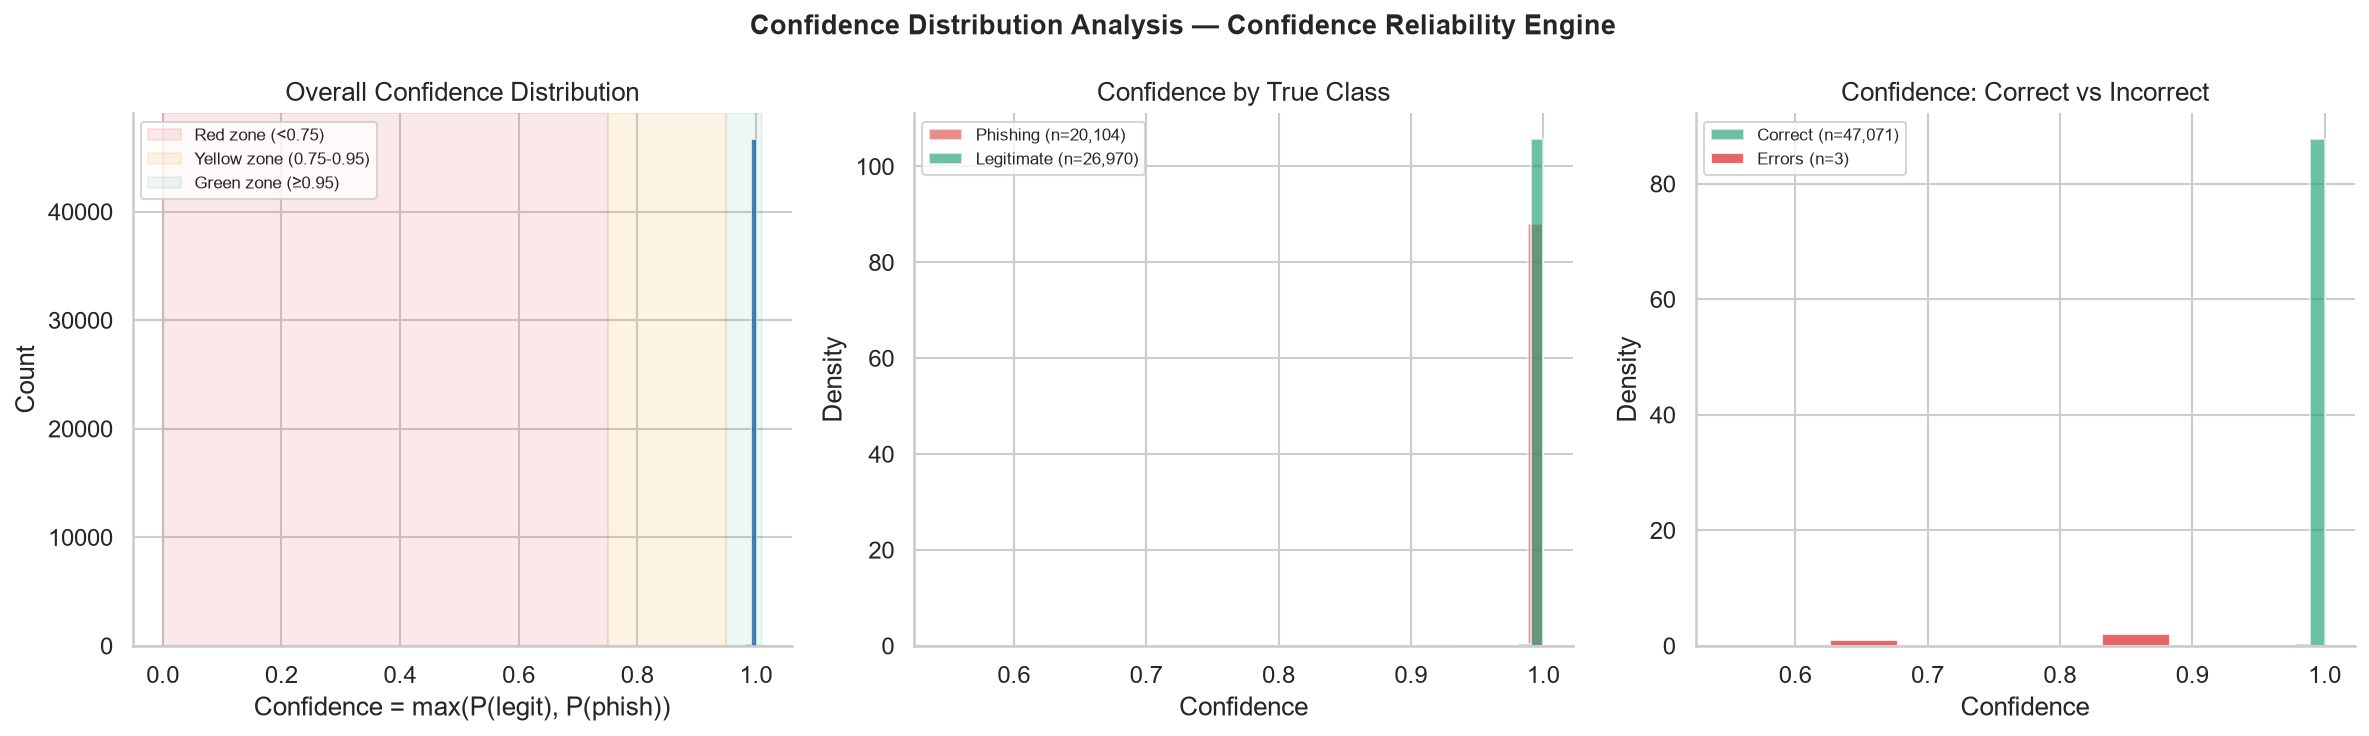

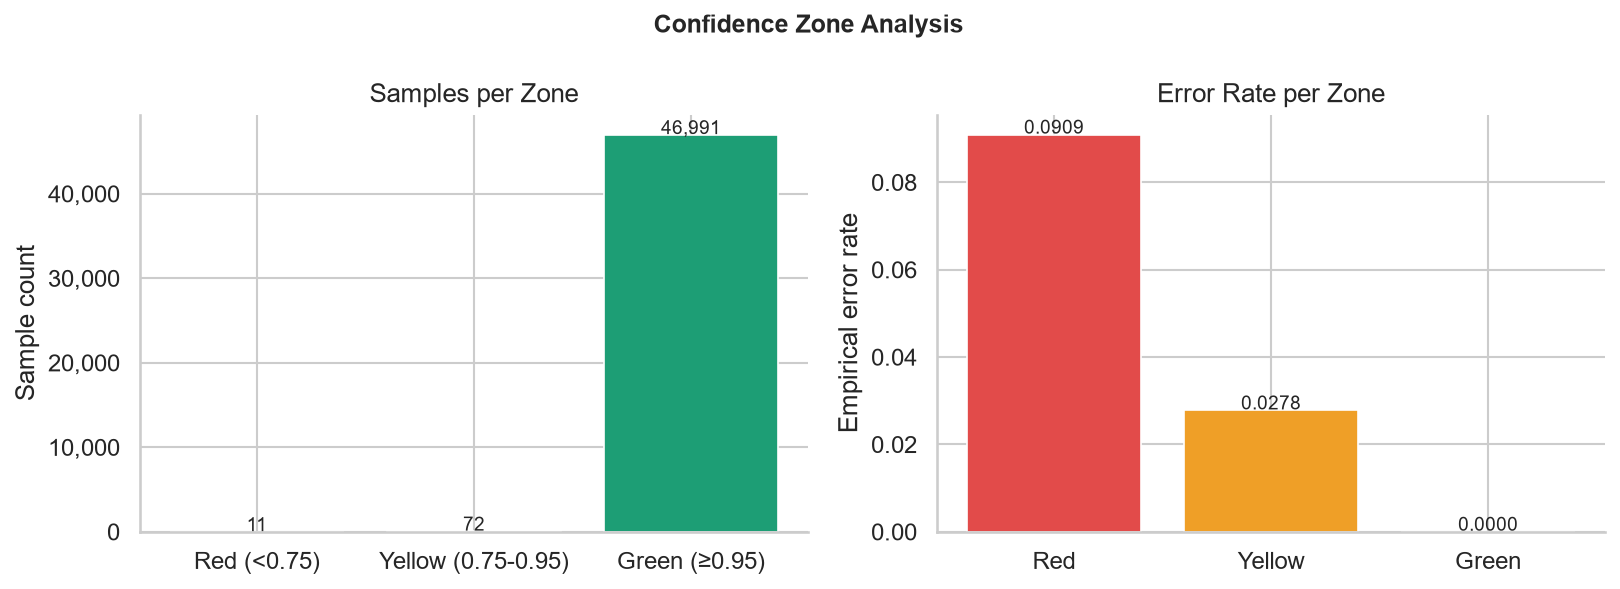

In [9]:
from IPython.display import Image
display(Image(str(uncertainty_r['confidence_dist_plot'])))
display(Image(str(uncertainty_r['zone_error_plot'])))

## 6. Severity Scoring & Top-20 Blind Spots

In [10]:
severity_df=compute_severity_scores(fcs,shap_result.shap_values,feature_names)
top_20_bs=rank_blind_spots(severity_df,top_n=20)
severity_df.to_csv(REPORTS_DIR/'blindspot_severity.csv',index=False)
top_20_bs.to_csv(REPORTS_DIR/'top20_blind_spots.csv',index=False)
print(f'Severity scores: {len(severity_df)}')
print(f'Max severity: {severity_df["severity_score_norm"].max():.4f}')
print(f'Mean severity: {severity_df["severity_score_norm"].mean():.4f}')

2026-06-22 20:02:07 | INFO     | src.blindspots.severity_ranker           | Severity scores computed: 103 cases  max_score=1.0000  mean_score=0.1044
2026-06-22 20:02:07 | INFO     | src.blindspots.severity_ranker           | Top-20 blind spots:  errors=3  red_zone=1  max_severity=1.0000


Severity scores: 103
Max severity: 1.0000
Mean severity: 0.1044


In [11]:
print('Top-20 Blind Spots:')
display(top_20_bs[['severity_rank','sample_idx','confidence_zone',
                    'is_error','confidence','severity_score_norm','risk_level']].head(10))

Top-20 Blind Spots:


,severity_rank,sample_idx,confidence_zone,is_error,confidence,severity_score_norm,risk_level
0,1,17372,red,True,0.626135,1.000000,CRITICAL
1,2,11301,yellow,True,0.874598,0.893081,CRITICAL
2,3,30588,yellow,True,0.883466,0.889264,CRITICAL
3,4,20604,green,False,0.998416,0.266037,LOW
4,5,23614,green,False,0.999912,0.265393,LOW
5,6,4397,green,False,0.999988,0.265362,LOW
6,7,21286,green,False,0.999998,0.265357,LOW
7,7,9346,green,False,0.999996,0.265357,LOW
8,7,32758,green,False,0.999998,0.265357,LOW
9,7,36372,green,False,0.999996,0.265357,LOW


## 7. Failure Archetype Discovery (auto-clustering)

In [12]:
archetype_r=discover_archetypes(fcs,X_test_B,feature_names,
    shap_result.shap_values,k_range=(2,8))
archetype_r.archetype_df.to_csv(REPORTS_DIR/'failure_archetypes.csv',index=False)
print(f'Archetypes: {archetype_r.n_clusters}  silhouette={archetype_r.silhouette_score:.4f}')
for m in archetype_r.cluster_meta:
    print(f'  [{m["cluster"]}] {m["label"]} — n={m["n_samples"]}  errors={m["n_errors"]}')

2026-06-22 20:02:07 | INFO     | src.blindspots.failure_archetype_discovery | Discovering archetypes from 103 failure cases …
2026-06-22 20:02:10 | INFO     | src.blindspots.failure_archetype_discovery | Auto-k: best k=3  silhouette=0.1876
2026-06-22 20:02:11 | INFO     | src.blindspots.failure_archetype_discovery | Archetypes discovered: 3 clusters  silhouette=0.1874  PCA_var=0.640
2026-06-22 20:02:11 | INFO     | src.blindspots.failure_archetype_discovery |   [0] Non-HTTPS+Gov/Edu domain+Password-form: n=13 errors=1
2026-06-22 20:02:11 | INFO     | src.blindspots.failure_archetype_discovery |   [1] HTTPS+Gov/Edu domain+Social-linked: n=30 errors=0
2026-06-22 20:02:11 | INFO     | src.blindspots.failure_archetype_discovery |   [2] Non-HTTPS+Gov/Edu domain+Social-linked: n=60 errors=2


Archetypes: 3  silhouette=0.1874
  [0] Non-HTTPS+Gov/Edu domain+Password-form — n=13  errors=1
  [1] HTTPS+Gov/Edu domain+Social-linked — n=30  errors=0
  [2] Non-HTTPS+Gov/Edu domain+Social-linked — n=60  errors=2


## 8. Cluster Visualisations

findfont: Failed to find font weight 600, now using 700.
2026-06-22 20:02:12 | INFO     | src.blindspots.cluster_visualization     | Saved: pca_cluster_map.png
2026-06-22 20:02:12 | INFO     | src.blindspots.cluster_visualization     | Saved: confidence_heatmap.png
findfont: Failed to find font weight 600, now using 700.
2026-06-22 20:02:29 | INFO     | src.blindspots.cluster_visualization     | Saved: failure_density.png
2026-06-22 20:02:29 | INFO     | src.blindspots.cluster_visualization     | UMAP not available — skipping UMAP plot (pip install umap-learn)


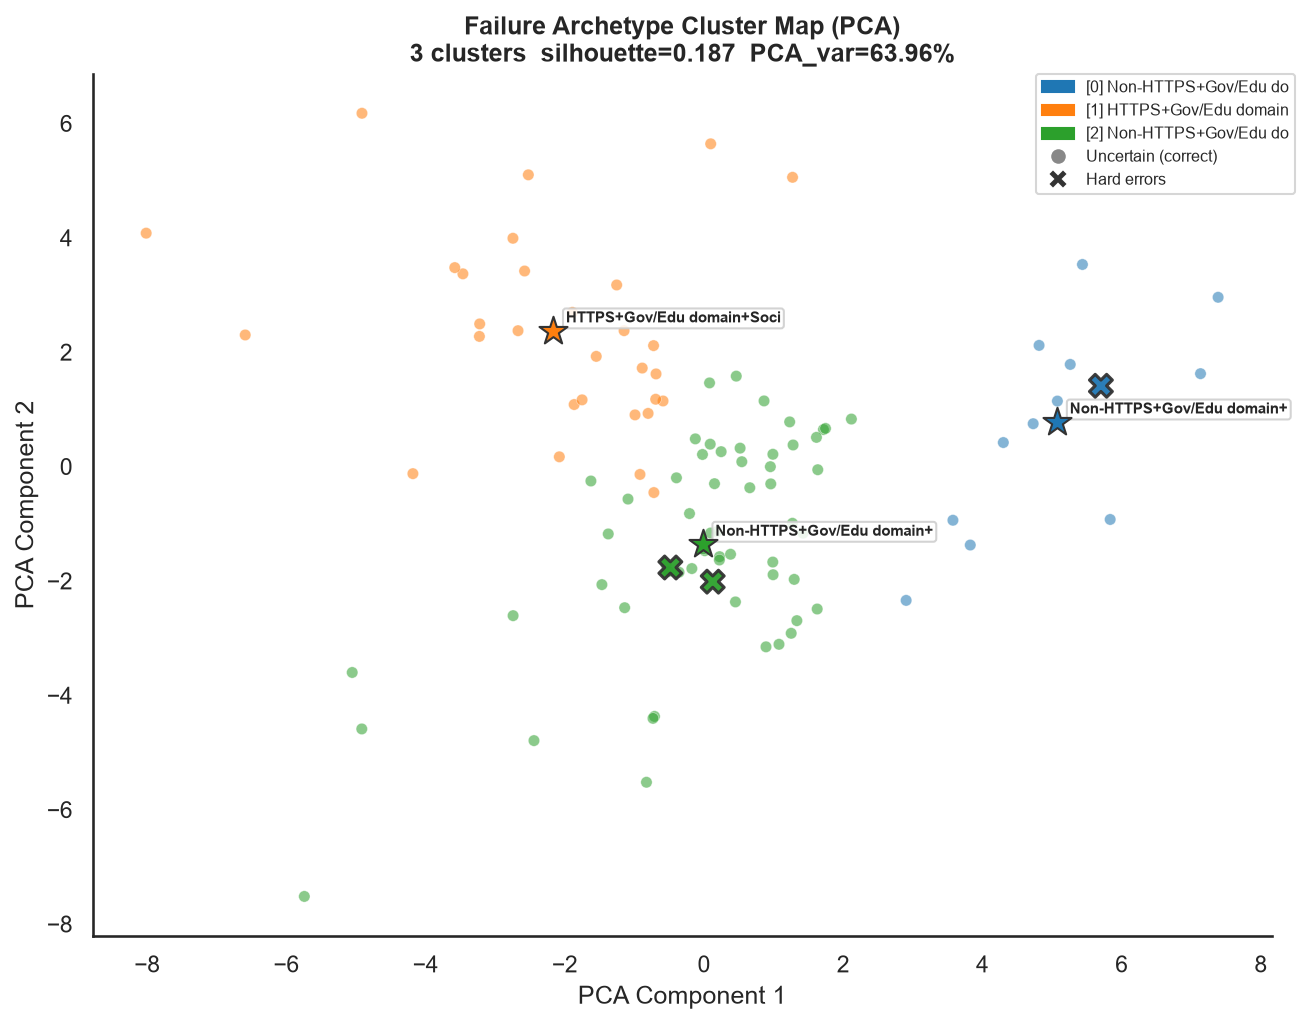

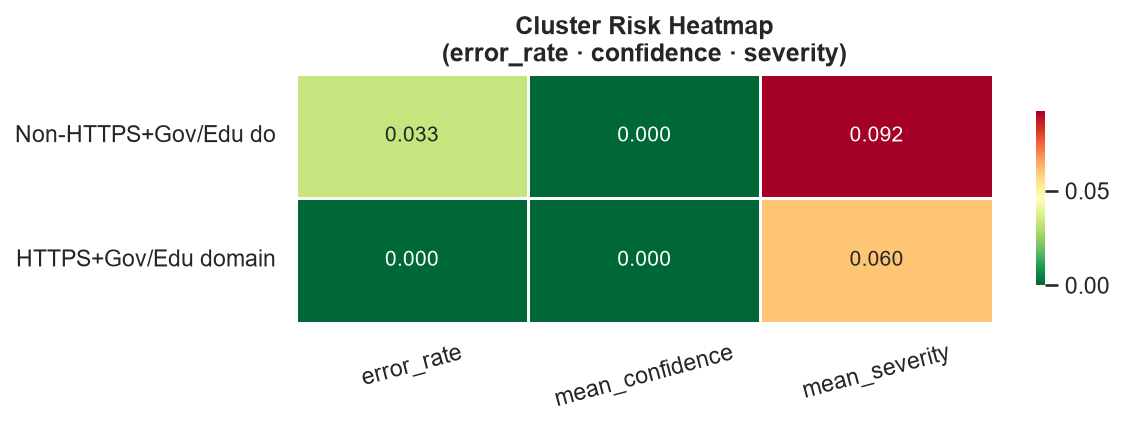

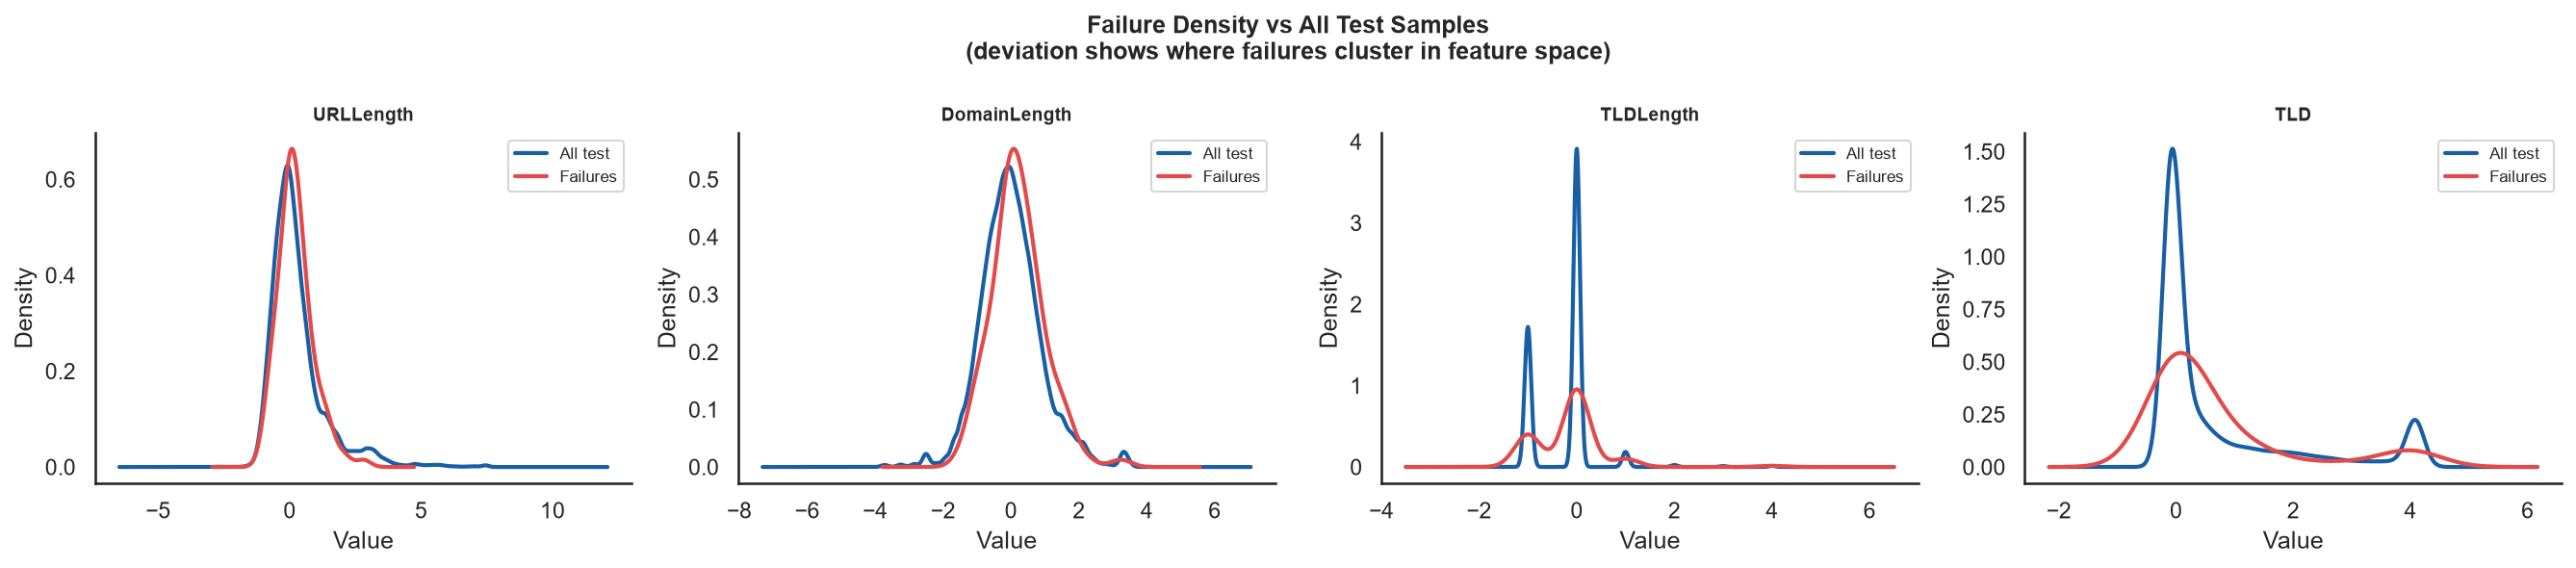

In [13]:
cluster_r=run_cluster_visualization(archetype_r,fcs,severity_df,
    X_test_B,feature_names,plots_dir=PLOTS_BS/'clusters')
display(Image(str(cluster_r['pca_plot'])))
display(Image(str(cluster_r['heatmap_plot'])))
display(Image(str(cluster_r['density_plot'])))

## 9. SHAP Failure Analysis

Top failure-zone features:
['LineOfCode', 'LetterRatioInURL', 'IsHTTPS', 'NoOfDegitsInURL', 'DomainLength']


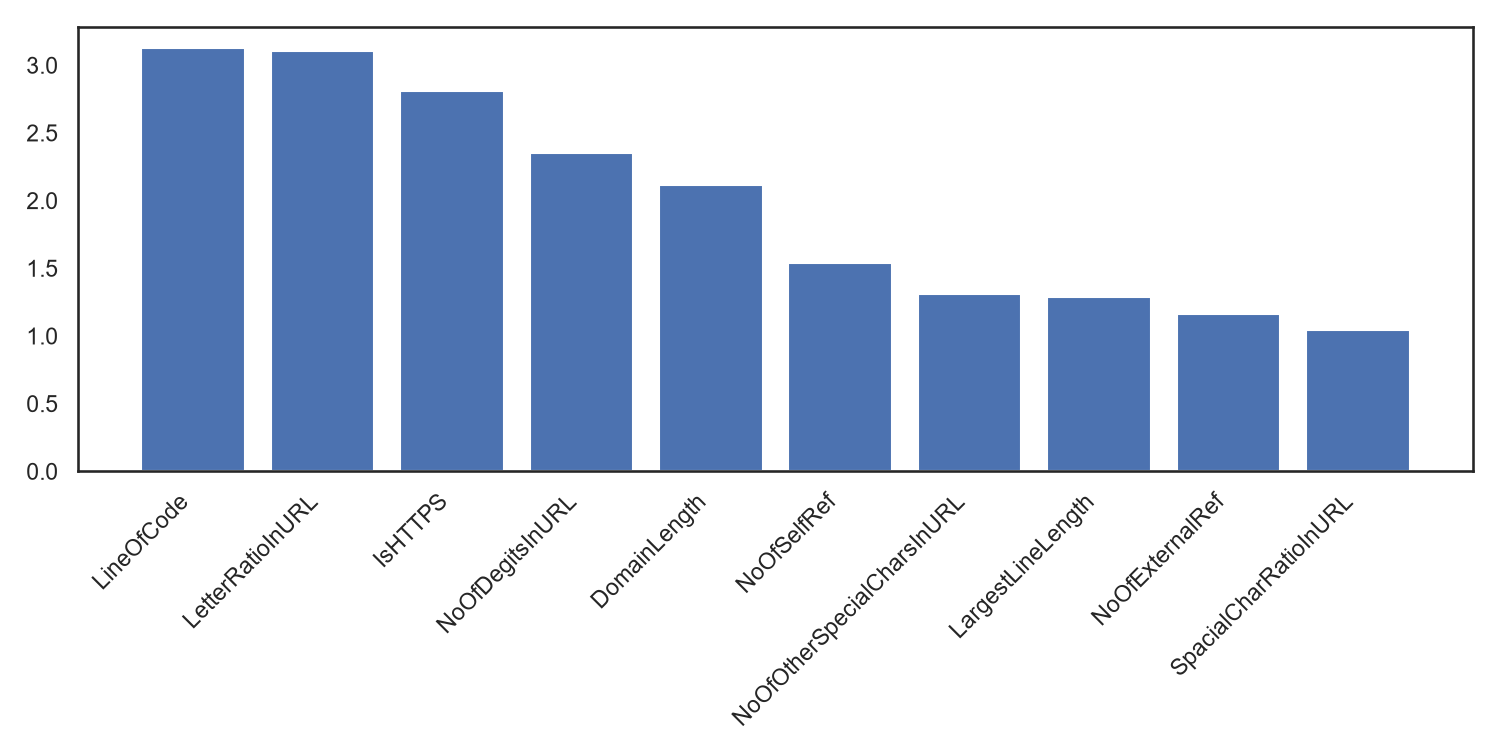

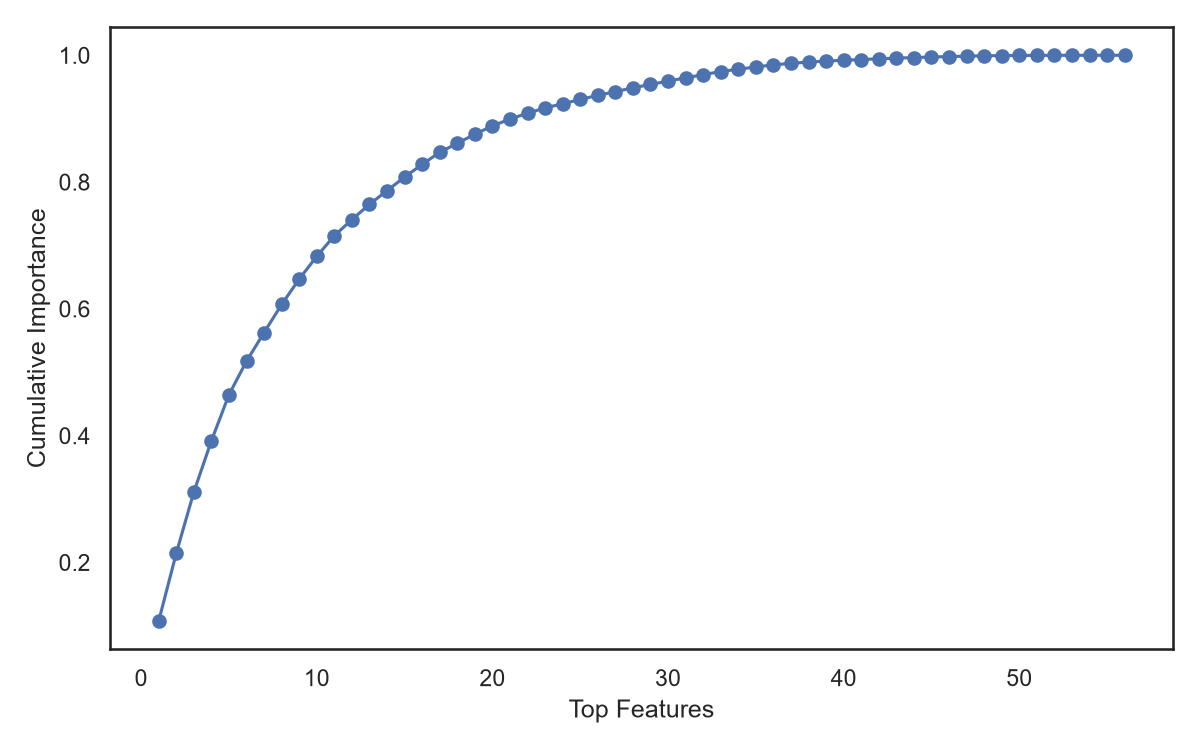

In [14]:
shap_fail_r=run_shap_failure_analysis(
    shap_result.shap_values,feature_names,fcs,y_true,y_proba,
    plots_dir=PLOTS_BS/'shap_failure',reports_dir=REPORTS_DIR)
print('Top failure-zone features:')
print(shap_fail_r['comparison']['top_failure_features'][:5])
display(Image(str(shap_fail_r['comparison_plot'])))
display(Image(str(shap_fail_r['masking_plot'])))

## 10. LIME Failure Analysis

In [15]:
lime_fail_r=run_lime_failure_analysis(agreement_df,fcs,
    plots_dir=PLOTS_BS/'failure_archetypes',reports_dir=REPORTS_DIR)
print(f'LIME failure features: {len(lime_fail_r["lime_freq_df"])} rows')
if not lime_fail_r['lime_freq_df'].empty:
    display(lime_fail_r['lime_freq_df'].head(10))

LIME failure features: 24 rows


,feature,count
0,LetterRatioInURL|LineOfCode|DomainLength|NoOfS...,23
1,NoOfDegitsInURL <= 0.00|IsDomainIP <= 0.00|Lin...,1
2,NoOfDegitsInURL <= 0.00|ObfuscationRatio <= 0....,1
3,NoOfDegitsInURL <= 0.00|LineOfCode > 0.26|HasO...,1
4,NoOfDegitsInURL <= 0.00|DomainLength > 0.45|No...,1
5,NoOfDegitsInURL > 0.00|LetterRatioInURL <= -0....,1
6,NoOfDegitsInURL <= 0.00|LetterRatioInURL <= -0...,1
7,NoOfDegitsInURL <= 0.00|LineOfCode > 0.26|NoOf...,1
8,NoOfDegitsInURL <= 0.00|NoOfAmpersandInURL <= ...,1
9,NoOfDegitsInURL <= 0.00|IsDomainIP <= 0.00|NoO...,1


## 11. SHAP-LIME Reliability Correlation

2026-06-22 20:02:32 | INFO     | src.blindspots.reliability_analysis      | M10 — SHAP-LIME RELIABILITY ANALYSIS
2026-06-22 20:02:32 | INFO     | src.blindspots.reliability_analysis      | Reliability Q1: Low-agree error rate=0.1304  High-agree error rate=nan  (No clear effect)
2026-06-22 20:02:32 | INFO     | src.blindspots.reliability_analysis      | Reliability Q2: Low-agree mean confidence=0.9732  High-agree=nan  (No clear effect)
2026-06-22 20:02:32 | INFO     | src.blindspots.reliability_analysis      | Reliability Q3: Low-agree mean severity=0.3517  High-agree=nan  (No clear effect)
2026-06-22 20:02:33 | INFO     | src.blindspots.reliability_analysis      | Saved: agreement_reliability.png
2026-06-22 20:02:33 | INFO     | src.blindspots.reliability_analysis      | Saved: reliability_bin_stats.csv


Q1: Low-agree error rate=0.1304  High-agree error rate=nan  (No clear effect)
Q2: Low-agree mean confidence=0.9732  High-agree=nan  (No clear effect)
Q3: Low-agree mean severity=0.3517  High-agree=nan  (No clear effect)
Corr(agreement, severity) = nan


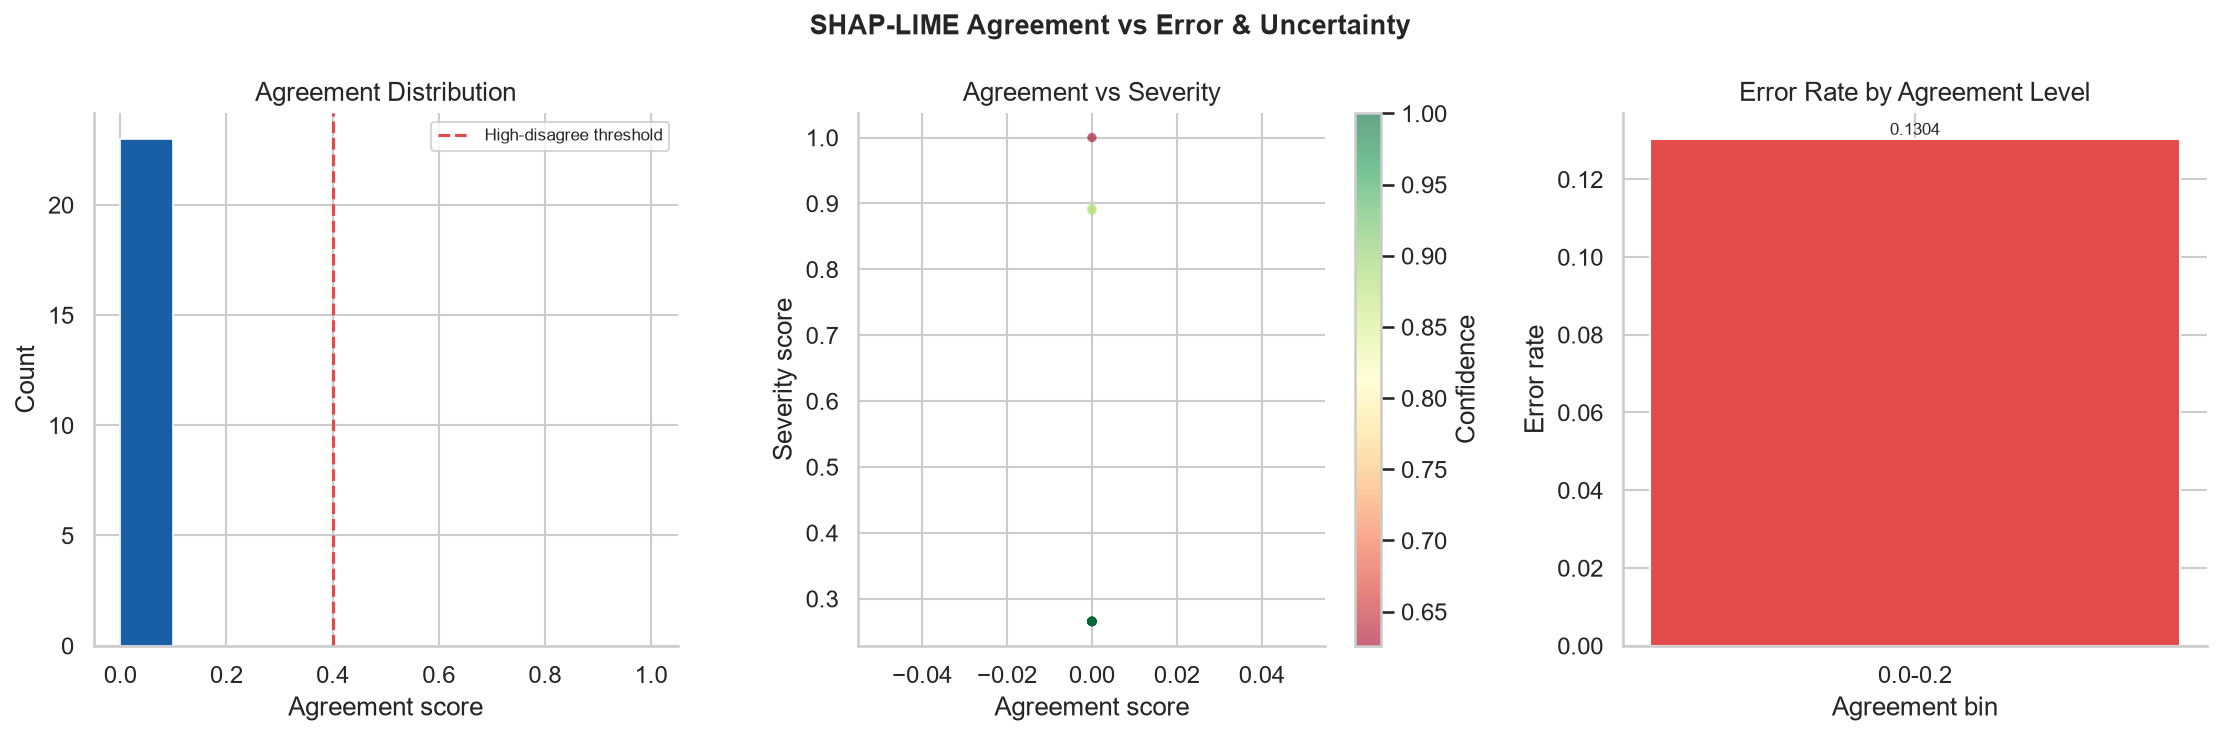

In [16]:
reliability_r=run_reliability_analysis(agreement_df,severity_df,
    uncertainty_r['zone_stats'],plots_dir=PLOTS_BS/'reliability',
    reports_dir=REPORTS_DIR)
rs=reliability_r['reliability_stats']
print(f'Q1: {rs.get("q1_answer","—")}')
print(f'Q2: {rs.get("q2_answer","—")}')
print(f'Q3: {rs.get("q3_answer","—")}')
print(f'Corr(agreement, severity) = {rs.get("corr_agreement_severity",0):.4f}')
if reliability_r.get('agreement_plot'):
    display(Image(str(reliability_r['agreement_plot'])))

## 12. HTML Report & Artifact Verification

In [17]:
m10_results={'fcs':fcs,'severity_df':severity_df,'top_20_bs':top_20_bs,
    'archetype_r':archetype_r,'uncertainty_r':uncertainty_r,'cluster_r':cluster_r,
    'shap_fail_r':shap_fail_r,'lime_fail_r':lime_fail_r,'reliability_r':reliability_r,
    'inputs':inputs,
    'summary':{'n_test':len(y_true),'n_errors':int((y_pred!=y_true).sum()),
               'n_fp':int(((y_pred==0)&(y_true==1)).sum()),
               'n_fn':int(((y_pred==1)&(y_true==0)).sum()),
               'error_rate':round(float((y_pred!=y_true).mean()),8),
               'n_failure_cases':len(fcs),'n_archetypes':archetype_r.n_clusters,
               'silhouette':round(archetype_r.silhouette_score,4),
               'green_zone_n':zs['green']['n'],'yellow_zone_n':zs['yellow']['n'],
               'red_zone_n':zs['red']['n'],
               'max_severity':round(float(severity_df['severity_score_norm'].max()),4),
               'mean_severity':round(float(severity_df['severity_score_norm'].mean()),4),
               'top_archetype':archetype_r.cluster_meta[0]['label'] if archetype_r.cluster_meta else '—',
               'shap_top_failure_feat':shap_fail_r['comparison']['top_failure_features'][0] if shap_fail_r['comparison'].get('top_failure_features') else '—'}}

report_path=generate_blindspot_report(m10_results,REPORTS_DIR/'blindspot_analysis_report.html',PLOTS_BS)
print(f'Report: {report_path}')

2026-06-22 20:02:33 | INFO     | src.blindspots.blindspot_report          | Blindspot report saved: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports\blindspot_analysis_report.html


Report: C:\Users\admin\Desktop\VS CODE\Explainable-Bias-Aware-Phishing-Detection\outputs\reports\blindspot_analysis_report.html


In [18]:
import pathlib
artifacts=['outputs/reports/blindspot_severity.csv','outputs/reports/top20_blind_spots.csv',
    'outputs/reports/failure_archetypes.csv','outputs/reports/blindspot_shap_failure.csv',
    'outputs/reports/blindspot_analysis_report.html']
for rel in artifacts:
    p=PROJECT_ROOT/rel
    print(f"  {'✓' if p.exists() else '✗'}  {rel}")

  ✓  outputs/reports/blindspot_severity.csv
  ✓  outputs/reports/top20_blind_spots.csv
  ✓  outputs/reports/failure_archetypes.csv
  ✓  outputs/reports/blindspot_shap_failure.csv
  ✓  outputs/reports/blindspot_analysis_report.html


## 13. Dashboard-Ready Outputs

In [19]:
print('='*65)
print('M10 COMPLETE — DASHBOARD-READY OUTPUTS')
print('='*65)
print(f'  fcs                  : FailureCaseSet — {len(fcs)} cases')
print(f'  top_20_bs            : Top-20 blind spots DataFrame')
print(f'  archetype_r          : {archetype_r.n_clusters} archetypes discovered')
print(f'  severity_df          : {len(severity_df)} severity scores')
print(f'  uncertainty_r        : Green/Yellow/Red zone stats')
print(f'  reliability_r        : SHAP-LIME correlation analysis')
print(f'  cluster_r[pca_plot]  : PCA cluster map for dashboard')
print()
print('Next: M11 — Streamlit Dashboard')

M10 COMPLETE — DASHBOARD-READY OUTPUTS
  fcs                  : FailureCaseSet — 103 cases
  top_20_bs            : Top-20 blind spots DataFrame
  archetype_r          : 3 archetypes discovered
  severity_df          : 103 severity scores
  uncertainty_r        : Green/Yellow/Red zone stats
  reliability_r        : SHAP-LIME correlation analysis
  cluster_r[pca_plot]  : PCA cluster map for dashboard

Next: M11 — Streamlit Dashboard
